# detecting.expr1.fsize — plots

Layout from `run_detecting_expr1_fsize.sh`: **one** `walk_list_normal.csv` at `EXP_ROOT/` for the whole run; under `EXP_ROOT/<timer>/<combo>/` you get `meta.md` (and optional `meta.txt`) plus `<timer>_walks/w####_ta<ns>/` (CSV outputs). `combo` looks like `interval10000_fkerncopy_rkernnone_fsize4096` (optionally with `_rsize0`).

- **Left**: histogram of measured **ta** samples (ns) from all `partes_ta_r*.csv` for each timer (after optional combo filters).
- **Right**: ECDF with **x = cumulative probability**, **y = time (ns)**. Green: **theoretical ta** taken **directly from** `walk_list_normal.csv` column `ta_ns` (not a fitted Normal); orange: **measured ta** (same samples as the histogram).
- **If theory looks like a horizontal line at one ns (e.g. 10000)**: the walk list is **constant** — e.g. `gen_walklist.py --dist fixed` with one duration, or `NWALKS=1` with a single row. Then every theory point has the same `ta_ns`, so the ECDF is flat at that y. **Measured** still spreads because ParTES samples are noisy. For a **Gaussian** theory curve vs measured, use [`detecting_plot_fixed_0416.ipynb`](detecting_plot_fixed_0416.ipynb) (synthetic `N(mu, sigma_rel×mu)`), or generate walk lists with `--dist normal` and many walks.
- Uses **ta** only; `partes_tb_*` is ignored.
- **Plot trimming**: keep values with `<= quantile(x, QUANTILE_KEEP)` (default `0.995`). Set `1.0` for no trim.
- Run parameters are read from `meta.md` / `meta.txt` under the **first matching combo** directory and shown on the figure.

In [21]:
from __future__ import annotations

from pathlib import Path
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Hyperparameters (tweak here)
# =========================



# Root folder of one experiment (timestamp dir under scripts/output/<host>/<expr>/)
DATA_ROOT = Path("/astrum/home/hpchzy/code/data")

DATETIME = "20260416"

EXPR_NAME = "detecting.expr1.timer"


# HOSTNAME = "camd9554n2"
# EXPR_NAME = "detecting.expr1.timer"
# TIMESTAMP = "20260416_132613" # 2KB,Robust=1


HOSTNAME = "cgnr6760pn2"
EXPR_NAME = "detecting.expr1.timer"
# TIMESTAMP = "20260416_131242" # 原方法，但32KB。理论和实测都几乎重合。
# TIMESTAMP = "20260416_140555" # Robust方法，32KB。和原方法对标
# TIMESTAMP = "20260416_133019" # Robust方法，2048KB。理论和实测偏差都很大
# TIMESTAMP = "20260416_135124" # Robust方法，64KB。理论和实测偏差都很大
# TIMESTAMP = "20260416_142138" # 原方法，2048KB。
# TIMESTAMP = "20260416_143245" # 原方法，2048KB。改cpupower锁频率（而非govorner）
TIMESTAMP = "20260416_145104" # 原方法，2048KB。不锁频

EXP_ROOT = Path(f"{DATA_ROOT}/{DATETIME}/output/{HOSTNAME}/{EXPR_NAME}/{TIMESTAMP}")
print(f"EXP_ROOT: {EXP_ROOT}")
# Used in plot title; should match the experiment folder name (e.g. detecting.expr1.fsize).
PLOT_TITLE_EXPR = EXPR_NAME
WALK_LIST_NAME = "walk_list_normal.csv"  # canonical: EXP_ROOT/; legacy: combo dir

# Combo filters (None = merge all matching combos for that timer).
# Combo names can be either:
# - interval10000_fkerncopy_rkernnone_fsize4096
# - interval10000_fkerncopy_rkernnone_fsize2048_rsize0
FSIZE_KIB: int | None = None  # e.g. 4096
INTERVAL_NS: int | None = None  # e.g. 10000
FKERN: str | None = None  # e.g. "copy"
RKERN: str | None = None  # e.g. "none"
RSIZE_KIB: int | None = None  # e.g. 0 (missing rsize in name is treated as 0)

# Upper-tail trim used for plotting/summary: keep x <= quantile(x, q); 1.0 disables trimming
QUANTILE_KEEP = 0.995

# Histogram binning strategy (left panel)
# - "none": no binning; draw a rug/strip of samples instead of a histogram
# - "fixed_width": fixed-width bins; specify FIXED_BIN_WIDTH_NS; the code will compute N_BINS
# - "auto": matplotlib's automatic binning (bins="auto")
HIST_BINNING: str = "fixed_width"  # "none" | "fixed_width" | "auto"
FIXED_BIN_WIDTH_NS: int = 50  # only used when HIST_BINNING == "fixed_width"

plt.rcParams["figure.dpi"] = 120
# ASCII-only default font for figures (avoid missing-glyph warnings)
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

EXP_ROOT: /astrum/home/hpchzy/code/data/20260416/output/cgnr6760pn2/detecting.expr1.timer/20260416_145104


In [22]:
import re


def _parse_combo(combo_name: str) -> dict[str, str]:
    """Parse combo directory name.

    Supported examples:
    - interval10000_fkerncopy_rkernnone_fsize4096
    - interval10000_fkerncopy_rkernnone_fsize2048_rsize0
    """
    out: dict[str, str] = {}
    for part in combo_name.split("_"):
        if not part:
            continue
        for k in ("interval", "fkern", "rkern", "fsize", "rsize"):
            if part.startswith(k):
                out[k] = part[len(k) :]
                break
    return out


def combo_dir_matches(
    combo_name: str,
    *,
    fsize_kib: int | None,
    interval_ns: int | None,
    fkern: str | None,
    rkern: str | None,
    rsize_kib: int | None,
) -> bool:
    """Filter combo directories under ``EXP_ROOT/<timer>/``."""
    info = _parse_combo(combo_name)

    if interval_ns is not None and int(info.get("interval", "-1")) != int(interval_ns):
        return False

    if fsize_kib is not None and int(info.get("fsize", "-1")) != int(fsize_kib):
        return False

    if fkern is not None and info.get("fkern") != str(fkern):
        return False

    if rkern is not None and info.get("rkern") != str(rkern):
        return False

    # Some older combos omit rsize (implicitly 0).
    if rsize_kib is not None:
        parsed = info.get("rsize")
        if parsed is None:
            return int(rsize_kib) == 0
        if int(parsed) != int(rsize_kib):
            return False

    return True


def list_timers(exp_root: Path) -> list[str]:
    """Top-level dirs under EXP_ROOT that contain at least one combo with ``<timer>_walks``."""
    timers: list[str] = []
    for p in sorted(exp_root.iterdir()):
        if not p.is_dir() or p.name.startswith("."):
            continue
        if p.name == "_archive":
            continue
        for combo in p.iterdir():
            if not combo.is_dir():
                continue
            walks = combo / f"{p.name}_walks"
            if walks.is_dir():
                timers.append(p.name)
                break
    return timers


def combo_dirs_for_timer(
    exp_root: Path,
    timer: str,
    *,
    fsize_kib: int | None,
    interval_ns: int | None,
    fkern: str | None,
    rkern: str | None,
    rsize_kib: int | None,
) -> list[Path]:
    base = exp_root / timer
    if not base.is_dir():
        return []
    out: list[Path] = []
    for combo in sorted(base.iterdir()):
        if not combo.is_dir():
            continue
        if not combo_dir_matches(
            combo.name,
            fsize_kib=fsize_kib,
            interval_ns=interval_ns,
            fkern=fkern,
            rkern=rkern,
            rsize_kib=rsize_kib,
        ):
            continue
        walks = combo / f"{timer}_walks"
        if not walks.is_dir():
            continue
        out.append(combo)
    return out


def load_theory_ta_ns_shared(exp_root: Path, combos: list[Path]) -> np.ndarray:
    """Load ``ta_ns`` from ``EXP_ROOT/walk_list_normal.csv`` (current ``run_detecting_expr*.sh`` layout).

    Falls back to the first combo that still has a per-combo ``walk_list_normal.csv`` (older runs).
    """
    p_root = exp_root / WALK_LIST_NAME
    if p_root.is_file():
        df = pd.read_csv(p_root)
        return df["ta_ns"].to_numpy(dtype=np.int64)
    for cd in combos:
        p = cd / WALK_LIST_NAME
        if p.is_file():
            df = pd.read_csv(p)
            return df["ta_ns"].to_numpy(dtype=np.int64)
    return np.array([], dtype=np.int64)


def walk_run_dirs_from_combos(timer: str, combos: list[Path]) -> list[Path]:
    """All per-walk directories under ``<timer>_walks`` for the given combo dirs."""
    out: list[Path] = []
    for cd in combos:
        walks = cd / f"{timer}_walks"
        out.extend(sorted(w for w in walks.glob("w*") if w.is_dir()))
    return out


def load_ta_samples(walk_dirs: list[Path]) -> np.ndarray:
    blocks: list[np.ndarray] = []
    for wd in walk_dirs:
        for f in sorted(wd.glob("partes_ta_r*.csv")):
            arr = np.loadtxt(f, dtype=np.int64)
            if arr.ndim == 0:
                arr = np.array([arr], dtype=np.int64)
            blocks.append(arr.ravel())
    if not blocks:
        return np.array([], dtype=np.int64)
    return np.concatenate(blocks, axis=0)


def ecdf_p_vs_t(x: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """ECDF: x = cumulative probability p, y = sorted time (ns)."""
    if x.size == 0:
        return np.array([]), np.array([])
    t = np.sort(x.astype(float))
    n = t.size
    p = (np.arange(1, n + 1) - 0.5) / n
    return p, t


def trim_upper_tail(x: np.ndarray, q_keep: float) -> np.ndarray:
    """Upper-tail trim: keep values with x <= quantile(x, q_keep). q_keep >= 1.0 returns x unchanged."""
    if x.size == 0 or q_keep >= 1.0:
        return x
    cap = float(np.quantile(x, q_keep))
    out = x[x <= cap]
    return out.astype(np.int64, copy=False) if out.dtype == np.int64 or x.dtype == np.int64 else out


def load_experiment_meta(meta_dir: Path) -> dict[str, str]:
    """Load ``key=value`` from ``meta.txt`` and markdown table rows from ``meta.md`` under ``meta_dir``."""
    out: dict[str, str] = {}
    p_txt = meta_dir / "meta.txt"
    if p_txt.is_file():
        for line in p_txt.read_text().splitlines():
            line = line.strip()
            if not line or line.startswith("#") or "=" not in line:
                continue
            k, _, v = line.partition("=")
            out[k.strip()] = v.strip()
    p_md = meta_dir / "meta.md"
    if p_md.is_file():
        for m in re.finditer(
            r"^\|\s*([^|\n]+?)\s*\|\s*`([^`]*)`\s*\|",
            p_md.read_text(),
            re.MULTILINE,
        ):
            k = m.group(1).strip()
            if not k or k in ("Key", "Parameter", "Item") or k.startswith("---"):
                continue
            out[k] = m.group(2).strip()
    return out


def format_experiment_meta_line(meta: dict[str, str]) -> str:
    """Compact annotation from combo ``meta.md`` (see ``run_detecting_expr*.sh``)."""
    parts: list[str] = []
    order: list[tuple[str, str]] = [
        ("expr_name", "expr"),
        ("timestamp", "ts"),
        ("interval_ns", "interval_ns"),
        ("walk_mu_ns", "walk_mu_ns"),
        ("walk_fixed_ns", "walk_fixed_ns"),
        ("np", "np"),
        ("ntests", "ntests"),
        ("ntiles", "ntiles"),
        ("cut-p", "cut_p"),
        ("gauge", "gauge"),
        ("fkern", "fkern"),
        ("fsize_kib", "fsize_kiB"),
        ("fsize_list (KiB)", "fsize_list_KiB"),
        ("rkern", "rkern"),
        ("rsize (KiB)", "rsize_KiB"),
        ("nwalks", "nwalks"),
        ("mu_ns", "mu_ns"),
        ("sigma_rel", "sigma_rel"),
    ]
    for md_key, label in order:
        v = meta.get(md_key)
        if v is not None and str(v).strip() != "":
            parts.append(f"{label}={v}")
    return "  |  ".join(parts)


def hist_edges_fixed_width(x: np.ndarray, bin_width_ns: int) -> np.ndarray:
    """Compute fixed-width histogram edges. Returns (n_bins+1) edges."""
    if x.size == 0:
        return np.array([0.0, float(bin_width_ns)])
    if bin_width_ns <= 0:
        raise ValueError("FIXED_BIN_WIDTH_NS must be > 0")
    x_min = float(np.min(x))
    x_max = float(np.max(x))
    if x_max == x_min:
        return np.array([x_min - 0.5, x_max + 0.5])

    start = np.floor(x_min / bin_width_ns) * bin_width_ns
    stop = np.ceil(x_max / bin_width_ns) * bin_width_ns
    n_bins = int(max(1, round((stop - start) / bin_width_ns)))
    edges = start + np.arange(n_bins + 1, dtype=float) * float(bin_width_ns)
    return edges


def plot_left_panel(ax, x: np.ndarray) -> dict[str, float | int | str]:
    """Draw the left panel and return info about the binning used."""
    info: dict[str, float | int | str] = {"mode": HIST_BINNING}

    if HIST_BINNING == "none":
        # Rug plot (no binning)
        if x.size:
            ax.plot(
                x.astype(float),
                np.zeros_like(x, dtype=float),
                "|",
                color="steelblue",
                alpha=0.25,
                markersize=6,
            )
        ax.set_ylabel("")
        ax.set_yticks([])
        ax.set_xlabel("Time (ns)")
        info["n"] = int(x.size)
        return info

    if HIST_BINNING == "fixed_width":
        edges = hist_edges_fixed_width(x.astype(float), int(FIXED_BIN_WIDTH_NS))
        n_bins = int(edges.size - 1)
        ax.hist(x, bins=edges, color="steelblue", edgecolor="white", linewidth=0.3)
        ax.set_xlabel("Time (ns)")
        ax.set_ylabel("Count")
        info["bin_width_ns"] = int(FIXED_BIN_WIDTH_NS)
        info["n_bins"] = n_bins
        return info

    if HIST_BINNING == "auto":
        ax.hist(x, bins="auto", color="steelblue", edgecolor="white", linewidth=0.3)
        ax.set_xlabel("Time (ns)")
        ax.set_ylabel("Count")
        return info

    raise ValueError(f"Unknown HIST_BINNING: {HIST_BINNING!r}")

In [23]:
# =========================
# Data loading (run once)
# =========================

exp_root = Path(EXP_ROOT).resolve()
timers = list_timers(exp_root)

_combo_kw = dict(
    fsize_kib=FSIZE_KIB,
    interval_ns=INTERVAL_NS,
    fkern=FKERN,
    rkern=RKERN,
    rsize_kib=RSIZE_KIB,
)

exp_meta: dict[str, str] = {}
_seed_combos: list[Path] = []
if timers:
    first_combos = combo_dirs_for_timer(exp_root, timers[0], **_combo_kw)
    if first_combos:
        exp_meta = load_experiment_meta(first_combos[0])
    for _tm in timers:
        _seed_combos = combo_dirs_for_timer(exp_root, _tm, **_combo_kw)
        if _seed_combos:
            break

# Shared theory walk list (ta_ns): run_detecting_expr1_fsize.sh places it at EXP_ROOT.
theory_ta_ns_shared = load_theory_ta_ns_shared(exp_root, _seed_combos)

# Cache raw measured samples by timer so you can tweak plotting without re-reading CSVs.
measured_ta_by_timer: dict[str, np.ndarray] = {}

table_rows: list[dict[str, object]] = []
for tm in timers:
    combos = combo_dirs_for_timer(exp_root, tm, **_combo_kw)

    walks = walk_run_dirs_from_combos(tm, combos)
    measured = load_ta_samples(walks)
    measured_ta_by_timer[tm] = measured

    n_csv = sum(len(list(w.glob("partes_ta_r*.csv"))) for w in walks)
    table_rows.append(
        {
            "timer": tm,
            "n_combos": len(combos),
            "n_walks": len(walks),
            "n_partes_ta_csv": n_csv,
            "n_samples": int(measured.size),
            "n_after_trim": int(trim_upper_tail(measured, QUANTILE_KEEP).size),
        }
    )

summary = pd.DataFrame(table_rows)

print("EXP_ROOT:", exp_root)
print("Meta (summary):", format_experiment_meta_line(exp_meta))
print("Combo filters:", _combo_kw)
if theory_ta_ns_shared.size:
    print(
        "Theory ta_ns (shared):",
        theory_ta_ns_shared.size,
        "| min/max:",
        int(theory_ta_ns_shared.min()),
        int(theory_ta_ns_shared.max()),
    )
print("QUANTILE_KEEP=", QUANTILE_KEEP)
print()
print(summary.to_string(index=False))

EXP_ROOT: /astrum/home/hpchzy/code/data/20260416/output/cgnr6760pn2/detecting.expr1.timer/20260416_145104
Meta (summary): expr=detecting.expr1.timer  |  ts=20260416_145104  |  interval_ns=10000  |  walk_mu_ns=10000  |  np=64  |  ntests=100  |  ntiles=100  |  cut_p=0.995  |  gauge=sub_scalar  |  fkern=copy  |  fsize_kiB=2048  |  rkern=none
Combo filters: {'fsize_kib': None, 'interval_ns': None, 'fkern': None, 'rkern': None, 'rsize_kib': None}
Theory ta_ns (shared): 100 | min/max: 9559 10469
QUANTILE_KEEP= 0.995

        timer  n_combos  n_walks  n_partes_ta_csv  n_samples  n_after_trim
clock_gettime         1      100             6400     640000        636801
       likwid         1      100             6400     640000        636801
    mpi_wtime         1      100             6400     640000        636800
         papi         1      100             6400     640000        636802
       papix6         1      100             6400     640000        636801
     tsc_asym         1      100 

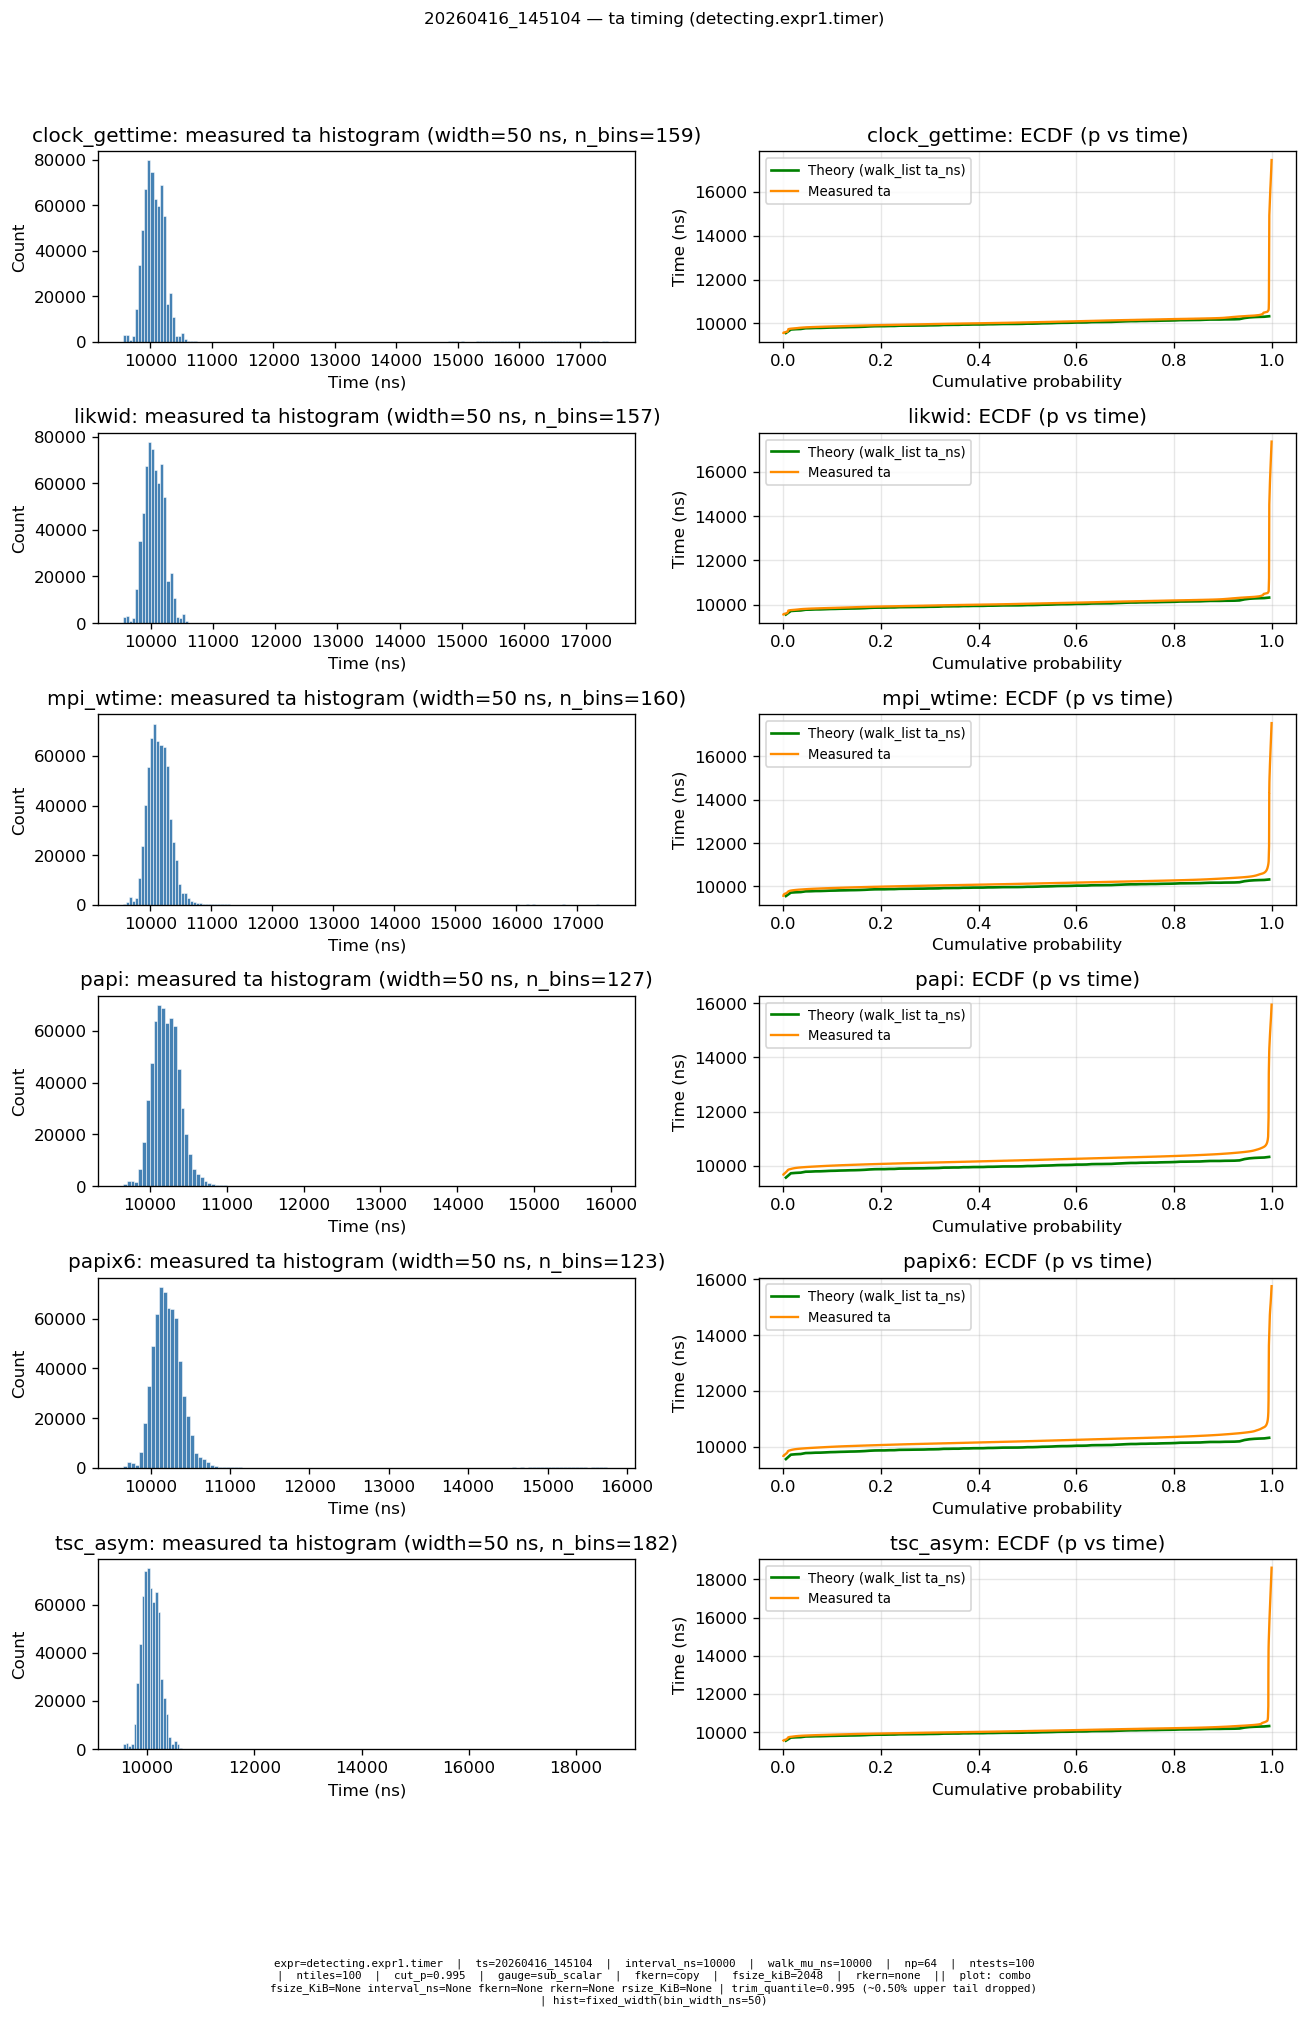

In [24]:
# =========================
# Data operations + plotting controls
# =========================

if not timers:
    raise RuntimeError("No timer directories found under EXP_ROOT")

n = len(timers)
fig, axes = plt.subplots(n, 2, figsize=(11, 2.9 * n), squeeze=False)

left_infos: list[dict[str, float | int | str]] = []
for i, tm in enumerate(timers):
    ax_left, ax_cdf = axes[i, 0], axes[i, 1]

    measured_raw = measured_ta_by_timer.get(tm, np.array([], dtype=np.int64))
    measured_plot = trim_upper_tail(measured_raw, QUANTILE_KEEP)

    theory_plot = trim_upper_tail(theory_ta_ns_shared, QUANTILE_KEEP)
    p_th, t_th = ecdf_p_vs_t(theory_plot)

    left_info = plot_left_panel(ax_left, measured_plot)
    left_infos.append({"timer": tm, **left_info})
    if HIST_BINNING == "none":
        ax_left.set_title(f"{tm}: measured ta (no binning)")
    elif HIST_BINNING == "fixed_width":
        ax_left.set_title(
            f"{tm}: measured ta histogram (width={FIXED_BIN_WIDTH_NS} ns, n_bins={left_info.get('n_bins','?')})"
        )
    else:
        ax_left.set_title(f"{tm}: measured ta histogram")

    p_m, t_m = ecdf_p_vs_t(measured_plot)
    ax_cdf.plot(p_th, t_th, label="Theory (walk_list ta_ns)", color="green", linewidth=1.6)
    ax_cdf.plot(p_m, t_m, label="Measured ta", color="darkorange", linewidth=1.4)
    ax_cdf.set_xlabel("Cumulative probability")
    ax_cdf.set_ylabel("Time (ns)")
    ax_cdf.set_title(f"{tm}: ECDF (p vs time)")
    ax_cdf.legend(loc="upper left", fontsize=8)
    ax_cdf.grid(True, alpha=0.3)

meta_line = format_experiment_meta_line(exp_meta)
plot_line = (
    f"plot: combo fsize_KiB={FSIZE_KIB} interval_ns={INTERVAL_NS} fkern={FKERN} rkern={RKERN} rsize_KiB={RSIZE_KIB} "
    f"| trim_quantile={QUANTILE_KEEP} (~{100 * (1 - QUANTILE_KEEP):.2f}% upper tail dropped)"
)
if HIST_BINNING == "fixed_width":
    plot_line += f" | hist=fixed_width(bin_width_ns={FIXED_BIN_WIDTH_NS})"
elif HIST_BINNING == "none":
    plot_line += " | hist=none(rug)"
else:
    plot_line += " | hist=auto"

footer = textwrap.fill(f"{meta_line}  ||  {plot_line}", width=118)
n_footer_lines = footer.count("\n") + 1
bottom_frac = min(0.06 + 0.019 * n_footer_lines, 0.42)

fig.suptitle(f"{exp_root.name} — ta timing ({PLOT_TITLE_EXPR})", fontsize=10, y=1.0)
fig.tight_layout(rect=[0, bottom_frac, 1, 0.97])
fig.text(
    0.5,
    bottom_frac * 0.5,
    footer,
    ha="center",
    va="top",
    fontsize=6.5,
    family="monospace",
    transform=fig.transFigure,
)
plt.show()

In [25]:
t_th

array([ 9559.,  9717.,  9732.,  9741.,  9775.,  9779.,  9788.,  9790.,
        9798.,  9807.,  9811.,  9818.,  9822.,  9828.,  9831.,  9837.,
        9846.,  9859.,  9867.,  9870.,  9870.,  9877.,  9878.,  9890.,
        9892.,  9894.,  9897.,  9899.,  9901.,  9907.,  9909.,  9913.,
        9926.,  9927.,  9931.,  9931.,  9941.,  9941.,  9947.,  9948.,
        9949.,  9957.,  9958.,  9963.,  9969.,  9970.,  9971.,  9972.,
        9976.,  9985.,  9985.,  9991., 10000., 10003., 10009., 10018.,
       10023., 10024., 10029., 10038., 10038., 10042., 10055., 10058.,
       10059., 10062., 10064., 10075., 10083., 10092., 10099., 10099.,
       10107., 10108., 10114., 10114., 10121., 10125., 10128., 10134.,
       10145., 10146., 10149., 10152., 10154., 10164., 10172., 10173.,
       10173., 10179., 10181., 10184., 10194., 10242., 10270., 10285.,
       10294., 10300., 10322.])